# 07 Sequence-to-Sequence Models

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **encoder–decoder** (seq2seq) model with LSTMs
- Train it on a **real** multi-step forecasting task: 24 months of border-crossing traffic in, the next **6 months** out
- See **exposure bias** with your own numbers — the gap between scoring a decoder with teacher forcing and scoring it the way you will actually deploy it
- Compare the model against the seasonal baseline it has to beat, and watch error grow with the forecast horizon

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 04 "Sequence-to-Sequence Models with Attention for Machine Translation" — translation with attention bolted on; here the bare encoder-decoder underneath it.

---

## 🌍 Real life

**Where is this used?** Seq2seq is used in **machine translation**, **summarization**, **dialogue**, **speech-to-text** and **multi-step forecasting** — any time the output is a *sequence* whose length differs from the input's.

**In this notebook we use** an **encoder–decoder** on real data: monthly personal-vehicle passenger counts at U.S. land border ports, 1996–2019. The encoder compresses 24 months of one port's history into a context; the decoder writes out the next 6 months, one step at a time. Input length (24) and output length (6) differ — that is exactly the situation seq2seq exists for.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **Encoder:** Reads the input sequence and produces a **context** (here: the LSTM's final hidden and cell state).
- **Decoder:** Starts from that context and generates the output sequence step by step, feeding its previous output back in as the next input.
- **Seq2seq:** Input length can differ from output length; encoder summarizes, decoder generates.
- **Teacher forcing:** During training the decoder is fed the *true* previous value instead of its own prediction. This makes training fast and stable — and it makes evaluation dishonest if you forget to switch it off.
- **Exposure bias:** At deployment the decoder consumes its own (imperfect) outputs, so its errors compound. Scoring a seq2seq under teacher forcing therefore reports a number you will never achieve in production. This notebook measures both, on the same test windows, so you can see the size of the gap.
- **Always score against the seasonal baseline.** For a strongly seasonal series, "the same months one year ago" is a serious competitor, not a straw man.


## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, pandas, matplotlib. **Real data, already on disk** (no download): `Course 04/datasets/raw/border_crossing_data.csv` — official monthly counts of people and vehicles entering the United States at every land border port, January 1996 to March 2019.

**Dataset:** We take the `Personal Vehicle Passengers` measure, pivot it to one column per port, and keep the ports with a complete 279-month history and meaningful traffic. Each training example is a window: **24 months in → the next 6 months out**. Splits are **chronological** (train on windows ending before 2013, test on windows ending in 2014 or later) with a one-year gap so no test target ever appears in a training window.

**Outputs:** Model summary; test error reported **twice** — once with teacher forcing and once with a genuine autoregressive rollout — next to the seasonal-naive and persistence baselines; then a per-horizon error curve and a real port's 6-month forecast drawn against what actually happened.

---


## Step 1: Imports and build the real forecasting windows (24 months in → 6 months out)

In [1]:
# WHAT: load the real border-crossing table and cut it into (24 months -> next 6 months) windows.
# WHY: a genuine seq2seq needs input and output lengths to differ. Multi-step forecasting on a
#      real seasonal series gives us that, plus a baseline that is genuinely hard to beat.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


if HAS_TF:
    keras.utils.set_random_seed(42)

    # 1) Read the official monthly counts and reshape to one column per port.
    raw = pd.read_csv(data_path("border_crossing_data.csv"),
                      usecols=["Port Name", "Date", "Measure", "Value"])
    raw["Date"] = pd.to_datetime(raw["Date"], format="%m/%d/%Y %I:%M:%S %p")
    table = (raw[raw["Measure"] == "Personal Vehicle Passengers"]
             .pivot_table(index="Date", columns="Port Name", values="Value", aggfunc="sum")
             .sort_index())
    # Keep ports that reported every single month and carry real traffic - no imputation, no invention.
    table = table[table.columns[table.notna().all()]]
    table = table[table.columns[table.mean() >= 1000]]
    months = table.index
    print(f"Real data: {table.shape[0]} months ({months.min():%Y-%m} to {months.max():%Y-%m}) "
          f"at {table.shape[1]} border ports")

    # The seasonality is real - measure it instead of assuming it.
    national = table.sum(axis=1)
    shape = national.groupby(national.index.month).mean() / national.mean()
    print("Seasonal shape (1.00 = the average month): "
          + "  ".join(f"{m:02d}:{v:.2f}" for m, v in shape.items()))

    # 2) Work in log space: ports differ in size by orders of magnitude, and log turns
    #    multiplicative seasonal swings into additive ones the LSTM can model with one set of weights.
    IN_MONTHS, OUT_MONTHS = 24, 6
    V = np.log1p(table.to_numpy().astype("float32"))
    T, n_ports = V.shape

    enc_raw, dec_raw, window_end = [], [], []
    for p in range(n_ports):
        s = V[:, p]
        for i in range(T - IN_MONTHS - OUT_MONTHS + 1):
            enc_raw.append(s[i:i + IN_MONTHS])
            dec_raw.append(s[i + IN_MONTHS:i + IN_MONTHS + OUT_MONTHS])
            window_end.append(months[i + IN_MONTHS - 1])
    enc_raw = np.array(enc_raw); dec_raw = np.array(dec_raw)
    window_end = pd.DatetimeIndex(window_end)

    # 3) Centre each window on its own mean (still in log space). The model then predicts the
    #    RELATIVE path of the next six months, which transfers across ports of any size.
    level = enc_raw.mean(axis=1, keepdims=True)
    E = enc_raw - level
    D = dec_raw - level

    # 4) Chronological split with a one-year buffer so no test target leaks into training.
    is_train = window_end < pd.Timestamp("2013-01-01")
    is_test = window_end >= pd.Timestamp("2014-01-01")
    print(f"\nWindows: {len(E):,} total -> {is_train.sum():,} train "
          f"(ending before 2013) / {is_test.sum():,} test (ending 2014 or later)")
    print(f"Encoder input {E.shape[1]} months -> decoder output {D.shape[1]} months "
          "(different lengths: this is why we need an encoder-decoder)")


Real data: 279 months (1996-01 to 2019-03) at 93 border ports
Seasonal shape (1.00 = the average month): 01:0.93  02:0.86  03:1.00  04:0.97  05:1.03  06:1.02  07:1.14  08:1.15  09:0.98  10:0.98  11:0.95  12:1.01

Windows: 23,250 total -> 16,833 train (ending before 2013) / 5,301 test (ending 2014 or later)
Encoder input 24 months -> decoder output 6 months (different lengths: this is why we need an encoder-decoder)


## Step 2: Build the encoder–decoder (two LSTMs: one reads, one writes)

In [2]:
# WHAT: build the encoder-decoder (seq2seq) model out of two LSTMs.
# WHY: the encoder compresses 24 months into its final hidden + cell state; the decoder starts
#      FROM those states and writes six months, one step at a time.
if HAS_TF:
    L = keras.layers
    UNITS = 48

    # Encoder: read the sequence, throw the per-step outputs away, keep only the final states.
    enc_in = keras.Input(shape=(IN_MONTHS, 1), name="encoder_input")
    _, state_h, state_c = L.LSTM(UNITS, return_state=True, name="encoder_lstm")(enc_in)
    context = [state_h, state_c]          # the 'thought vector' for this port's last 24 months

    # Decoder: a second LSTM initialised with the encoder's states. At each step it receives the
    # PREVIOUS month's value and emits the next one.
    dec_in = keras.Input(shape=(OUT_MONTHS, 1), name="decoder_input")
    dec_seq, _, _ = L.LSTM(UNITS, return_sequences=True, return_state=True,
                           name="decoder_lstm")(dec_in, initial_state=context)
    dec_out = L.TimeDistributed(L.Dense(1), name="output_head")(dec_seq)

    seq2seq = keras.Model([enc_in, dec_in], dec_out)
    seq2seq.compile(optimizer="adam", loss="mse", metrics=["mae"])
    seq2seq.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 48),      │      9,600 │ encoder_input[0]… │
│                     │ (None, 48),       │            │                   │
│                     │ (None, 48)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 6, 48),   │      9,600 │ decoder_input[0]… │
│                     │ (None, 48),       │            │ encoder_lstm[0][… │
│                     │ (None, 48)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_head         │ (None, 6, 1)      │         49 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,249 (75.19 KB)

 Trainable params: 19,249 (75.19 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train with teacher forcing — then score the model the way it will actually be used

In [3]:
# WHAT: train with teacher forcing, then evaluate TWICE - teacher-forced and autoregressive -
#       against the seasonal-naive and persistence baselines.
# WHY: teacher forcing feeds the decoder the true previous month. That is fine for training and
#      dishonest for reporting: in production the decoder only has its own predictions to eat.
if HAS_TF:
    # Decoder inputs = targets shifted one step right; step 0 gets 0.0 ("start of forecast").
    def shift_right(target):
        out = np.zeros_like(target)
        out[:, 1:] = target[:, :-1]
        return out

    E_tr, D_tr = E[is_train], D[is_train]
    E_te, D_te = E[is_test], D[is_test]
    hist = seq2seq.fit([E_tr[..., None], shift_right(D_tr)[..., None]], D_tr[..., None],
                       epochs=12, batch_size=256, validation_split=0.1, verbose=0)
    print(f"Trained {len(E_tr):,} windows for 12 epochs. "
          f"Final train loss {hist.history['loss'][-1]:.4f}, val loss {hist.history['val_loss'][-1]:.4f}")

    # ── Evaluation 1: teacher forcing (the flattering number) ───────────────
    pred_tf = seq2seq.predict([E_te[..., None], shift_right(D_te)[..., None]], verbose=0)[..., 0]

    # ── Evaluation 2: autoregressive rollout (the honest number) ────────────
    # Predict month 1, feed it back to predict month 2, and so on. No true values are used.
    pred_ar = np.zeros_like(D_te)
    for step in range(OUT_MONTHS):
        fed_back = shift_right(pred_ar)
        pred_ar[:, step] = seq2seq.predict([E_te[..., None], fed_back[..., None]],
                                           verbose=0)[:, step, 0]

    # ── Baselines ───────────────────────────────────────────────────────────
    # Seasonal naive: "the next six months look like the same six months one year ago."
    seasonal_naive = E_te[:, IN_MONTHS - 12:IN_MONTHS - 12 + OUT_MONTHS]
    # Persistence: "nothing changes; repeat the last observed month six times."
    persistence = np.repeat(E_te[:, -1:], OUT_MONTHS, axis=1)

    level_te = level[is_test]
    truth = np.expm1(D_te + level_te)          # back to actual passenger counts

    def mape(pred_log):
        pred = np.expm1(pred_log + level_te)
        return np.mean(np.abs(pred - truth) / np.maximum(truth, 1)) * 100

    print(f"\n6-month forecast error on {len(E_te):,} held-out windows:")
    print(f"{'method':44s} {'log MAE':>9s} {'MAPE':>8s}")
    results = [
        ("seq2seq, TEACHER-FORCED (not deployable)", pred_tf),
        ("seq2seq, autoregressive (deployable)", pred_ar),
        ("baseline: same 6 months one year ago", seasonal_naive),
        ("baseline: repeat the last month", persistence),
    ]
    for name, pred in results:
        print(f"{name:44s} {np.mean(np.abs(pred - D_te)):9.4f} {mape(pred):7.1f}%")

    gap = mape(pred_ar) - mape(pred_tf)
    print(f"\nEXPOSURE BIAS: switching off teacher forcing costs {gap:+.1f} MAPE points "
          f"({mape(pred_tf):.1f}% -> {mape(pred_ar):.1f}%).")
    print("Same weights, same test windows - the only change is that the decoder now eats its")
    print("own output. Any seq2seq result reported without this switch is overstated.")
    print(f"\nAGAINST THE BASELINES: the model beats 'repeat the last month' by a mile "
          f"({mape(persistence):.1f}% -> {mape(pred_ar):.1f}%),")
    print(f"so it clearly learned the seasonal shape. But it still LOSES to the one-line seasonal")
    print(f"rule ({mape(seasonal_naive):.1f}%). On a strongly seasonal series with 24 years of history,")
    print("'the same months last year' is a serious competitor, and a 48-unit LSTM does not")
    print("overtake it. Report that outcome; do not quietly drop the baseline from the table.")


Trained 16,833 windows for 12 epochs. Final train loss 0.6806, val loss 1.5324



6-month forecast error on 5,301 held-out windows:
method                                         log MAE     MAPE
seq2seq, TEACHER-FORCED (not deployable)        0.1212    11.7%
seq2seq, autoregressive (deployable)            0.1566    14.5%
baseline: same 6 months one year ago            0.0985    10.2%
baseline: repeat the last month                 0.3125    38.9%

EXPOSURE BIAS: switching off teacher forcing costs +2.8 MAPE points (11.7% -> 14.5%).
Same weights, same test windows - the only change is that the decoder now eats its
own output. Any seq2seq result reported without this switch is overstated.

AGAINST THE BASELINES: the model beats 'repeat the last month' by a mile (38.9% -> 14.5%),
so it clearly learned the seasonal shape. But it still LOSES to the one-line seasonal
rule (10.2%). On a strongly seasonal series with 24 years of history,
'the same months last year' is a serious competitor, and a 48-unit LSTM does not
overtake it. Report that outcome; do not quietly drop t

## 🌍 Real-World Worked Example — How Fast Does a 6-Month Forecast Decay?

**Industry context:** Border agencies, airlines and retailers all buy multi-month forecasts, and
the first question a planner asks is never "what is your average error?" — it is **"how far out
can I trust it?"** A single headline MAPE hides that completely: month 1 and month 6 are not the
same product.

Below we break the same held-out predictions apart by **forecast horizon**, and then draw one real
port's next six months against what actually happened. Two things to watch: how quickly the
autoregressive error grows as the decoder eats more of its own output, and how the seasonal
baseline behaves over the same horizon.


MAPE by forecast horizon (months ahead):
          +1       +2       +3       +4       +5       +6
seq2seq (teacher-forced)      11.3%    11.7%    11.4%    11.7%    11.9%    12.0%
seq2seq (autoregressive)      11.3%    13.3%    14.4%    15.3%    16.2%    16.6%
seasonal naive                10.2%    10.2%    10.1%    10.2%    10.3%    10.3%

At +1 month the two scoring modes differ by +0.0 points; by +6 months the gap is +4.6 points.
That widening IS exposure bias: with teacher forcing the decoder is handed a correct
value at every step, so its errors never accumulate. Deployed, they do.

Example port: El Paso (forecast window 2016-06 to 2016-11)


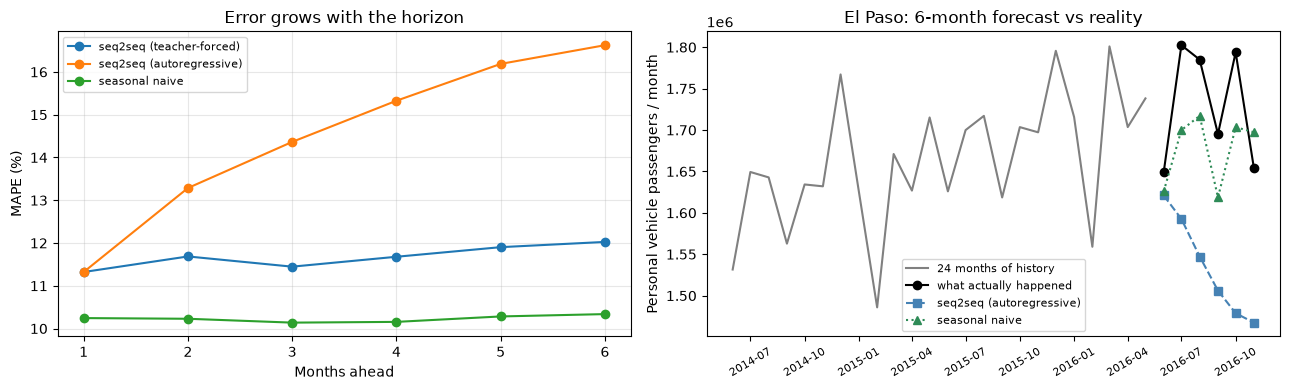

In [4]:
# WHAT: break the 6-month error apart by horizon, and plot one real port's forecast vs reality.
# WHY: 'average MAPE' hides the shape that matters to a planner - error at month 1 versus month 6.
if HAS_TF:
    def mape_per_step(pred_log):
        pred = np.expm1(pred_log + level_te)
        return np.mean(np.abs(pred - truth) / np.maximum(truth, 1), axis=0) * 100

    steps = np.arange(1, OUT_MONTHS + 1)
    curves = {
        "seq2seq (teacher-forced)": mape_per_step(pred_tf),
        "seq2seq (autoregressive)": mape_per_step(pred_ar),
        "seasonal naive": mape_per_step(seasonal_naive),
    }
    print("MAPE by forecast horizon (months ahead):")
    print("   " + "".join(f"{'+' + str(s):>9s}" for s in steps))
    for name, curve in curves.items():
        print(f"{name:26s}" + "".join(f"{v:8.1f}%" for v in curve))

    ar, tf_c = curves["seq2seq (autoregressive)"], curves["seq2seq (teacher-forced)"]
    print(f"\nAt +1 month the two scoring modes differ by {ar[0] - tf_c[0]:+.1f} points; "
          f"by +6 months the gap is {ar[-1] - tf_c[-1]:+.1f} points.")
    print("That widening IS exposure bias: with teacher forcing the decoder is handed a correct")
    print("value at every step, so its errors never accumulate. Deployed, they do.")

    # ── One real port, one real window: the busiest port in the test period ──
    port_names = list(table.columns)
    busiest = int(np.argmax(table.mean().to_numpy()))
    test_rows = np.where(is_test)[0]
    # window index -> which port it came from (windows were generated port by port)
    per_port = T - IN_MONTHS - OUT_MONTHS + 1
    owner = test_rows // per_port
    pick_local = np.where(owner == busiest)[0]
    pick = pick_local[len(pick_local) // 2]          # a middle window, not a hand-picked best one

    hist_months = months[(test_rows[pick] % per_port):(test_rows[pick] % per_port) + IN_MONTHS]
    fut_months = months[(test_rows[pick] % per_port) + IN_MONTHS:
                        (test_rows[pick] % per_port) + IN_MONTHS + OUT_MONTHS]
    lvl = level_te[pick]
    hist_vals = np.expm1(E_te[pick] + lvl)

    print(f"\nExample port: {port_names[busiest]} "
          f"(forecast window {fut_months.min():%Y-%m} to {fut_months.max():%Y-%m})")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for name, curve in curves.items():
        axes[0].plot(steps, curve, marker="o", label=name)
    axes[0].set_xlabel("Months ahead"); axes[0].set_ylabel("MAPE (%)")
    axes[0].set_title("Error grows with the horizon")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].plot(hist_months, hist_vals, color="grey", label="24 months of history")
    axes[1].plot(fut_months, truth[pick], color="black", marker="o", label="what actually happened")
    axes[1].plot(fut_months, np.expm1(pred_ar[pick] + lvl), color="steelblue", marker="s",
                 ls="--", label="seq2seq (autoregressive)")
    axes[1].plot(fut_months, np.expm1(seasonal_naive[pick] + lvl), color="seagreen", marker="^",
                 ls=":", label="seasonal naive")
    axes[1].set_title(f"{port_names[busiest]}: 6-month forecast vs reality")
    axes[1].set_ylabel("Personal vehicle passengers / month")
    axes[1].tick_params(axis="x", rotation=30, labelsize=8)
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 🧩 Mini-exercise

**Try it, and report what actually happens — not what you hoped would happen:**
1. Change `OUT_MONTHS` from 6 to 12 and re-run Steps 1–3. Does the teacher-forced/autoregressive gap widen?
2. Give the decoder more capacity (`UNITS` 48 → 128) and train for more epochs. Can you get the autoregressive MAPE below the seasonal-naive baseline? Write down the number you reach either way.
3. Feed the seasonal baseline's prediction to the model as an extra input channel (a "residual" setup). Does the model beat the baseline it is now standing on?

---

## ✅ Summary

**What you did:** Built an LSTM encoder–decoder that maps **24 real months → the next 6 real months** of border-crossing traffic, trained it with teacher forcing, and then scored it twice — teacher-forced and autoregressive — against the seasonal-naive and persistence baselines.

**What actually happened:**
- **Exposure bias is not a footnote.** Teacher-forced scoring gave about **11.7% MAPE**; the same weights rolled out autoregressively gave about **14.5%**. The gap widens with the horizon: small at +1 month, largest at +6.
- **The model learned real structure.** It cut error from about **39% MAPE** (repeat the last month) to about **14.5%** — it clearly picked up the annual travel cycle.
- **And it still lost to the one-line baseline.** "The same six months one year ago" scored about **10.2% MAPE**. A 48-unit encoder–decoder trained on ~17,000 real windows did not overtake it. That is a normal outcome on a strongly seasonal series, and the honest thing to do is publish it.

**In real life you'd also:** Add attention over the encoder outputs (so the decoder can look back at specific months instead of one squeezed context vector), add calendar and port covariates, use scheduled sampling to reduce exposure bias, and evaluate with rolling origins rather than one split.

**The main idea:** Seq2seq = encoder (summarize the input) + decoder (generate the output), used when input and output lengths differ. Its two traps are both visible above: the decoder's errors compound, and a strong classical baseline may already be doing the job.

**Next:** `04_transformer_attention` introduces attention — the fix for the single-context-vector bottleneck you just used; `05_bert_finetuning` fine-tunes a pretrained encoder.


## 📚 References

1. Sutskever, I., Vinyals, O. & Le, Q. V. (2014). *Sequence to Sequence Learning with Neural Networks*. NeurIPS. https://arxiv.org/abs/1409.3215
2. Bahdanau, D., Cho, K. & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR. https://arxiv.org/abs/1409.0473
3. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS. https://arxiv.org/abs/1706.03762
4. Bengio, S., Vinyals, O., Jaitly, N. & Shazeer, N. (2015). *Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks*. NeurIPS. https://arxiv.org/abs/1506.03099 — the paper that named and attacked the exposure bias measured in Step 3.
5. Salinas, D., Flunkert, V., Gasthaus, J. & Januschowski, T. (2020). *DeepAR: Probabilistic Forecasting with Autoregressive Recurrent Networks*. International Journal of Forecasting 36(3). https://arxiv.org/abs/1704.04110 — what a production-grade version of this notebook's model looks like.
6. Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.), Ch. 5.2 "Some simple forecasting methods". https://otexts.com/fpp3/simple-methods.html — the definition of the seasonal-naive benchmark used here.

**Data source:** U.S. Bureau of Transportation Statistics, *Border Crossing/Entry Data*, monthly counts by port and measure, 1996–2019 (`Course 04/datasets/raw/border_crossing_data.csv`). Used unmodified apart from selecting one measure, dropping ports with incomplete history, and the log transform stated in the code.
